<a href="https://colab.research.google.com/github/IshanAgr123/chest-xray-pneumonia-classifier/blob/main/Chest_xray_pneumonia_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ishanagrawal20","key":"61b7162b0fccb919ea0ece64aed2570f"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:33<00:00, 73.0MB/s]



In [3]:
!ls /content/chest_xray

chest_xray  __MACOSX  test  train  val


In [4]:
import os, numpy as np, torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_DIR = "/content/chest_xray"
IMG_SIZE, BATCH, EPOCHS, LR, SEED = 224, 32, 8, 1e-4, 42
torch.manual_seed(SEED); np.random.seed(SEED)
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

Device: cuda


In [5]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

full_train = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_tf)
test_ds    = datasets.ImageFolder(f"{DATA_DIR}/test",  transform=eval_tf)
print("Classes:", full_train.classes)

val_size = int(0.10 * len(full_train))
train_ds, val_ds = random_split(full_train, [len(full_train)-val_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))
val_ds.dataset = datasets.ImageFolder(f"{DATA_DIR}/train", transform=eval_tf)

Classes: ['NORMAL', 'PNEUMONIA']


In [6]:
targets = np.array(full_train.targets)
print("Counts:", dict(zip(full_train.classes, np.bincount(targets))))

train_targets = targets[train_ds.indices]
class_weights = 1.0 / np.bincount(train_targets)
sample_weights = class_weights[train_targets]
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights),
                                len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2)

Counts: {'NORMAL': np.int64(1341), 'PNEUMONIA': np.int64(3875)}


In [7]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


In [8]:
def run_epoch(loader, train):
    model.train() if train else model.eval()
    total=correct=0; loss_sum=0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            out = model(x); loss = criterion(out,y)
            if train: optimizer.zero_grad(); loss.backward(); optimizer.step()
        loss_sum += loss.item()*x.size(0)
        correct  += (out.argmax(1)==y).sum().item(); total += x.size(0)
    return loss_sum/total, correct/total

best_acc, best_state = 0.0, None
for ep in range(EPOCHS):
    tl,ta = run_epoch(train_loader, True)
    vl,va = run_epoch(val_loader, False)
    print(f"Epoch {ep+1}/{EPOCHS}  train_acc={ta:.3f}  val_acc={va:.3f}")
    if va > best_acc: best_acc, best_state = va, {k:v.cpu().clone() for k,v in model.state_dict().items()}
model.load_state_dict(best_state)
print("Best val acc:", round(best_acc,4))

Epoch 1/8  train_acc=0.958  val_acc=0.981
Epoch 2/8  train_acc=0.983  val_acc=0.969
Epoch 3/8  train_acc=0.985  val_acc=0.996
Epoch 4/8  train_acc=0.988  val_acc=0.988
Epoch 5/8  train_acc=0.990  val_acc=0.977
Epoch 6/8  train_acc=0.990  val_acc=0.987
Epoch 7/8  train_acc=0.992  val_acc=0.990
Epoch 8/8  train_acc=0.993  val_acc=0.981
Best val acc: 0.9962


In [9]:
model.eval(); all_probs=[]; all_preds=[]; all_true=[]
with torch.no_grad():
    for x,y in test_loader:
        out = model(x.to(device))
        all_probs += torch.softmax(out,1)[:,1].cpu().tolist()
        all_preds += out.argmax(1).cpu().tolist()
        all_true  += y.tolist()
all_true,all_preds,all_probs = map(np.array,(all_true,all_preds,all_probs))

print("Test accuracy:", round((all_preds==all_true).mean(),4))
print("ROC-AUC:", round(roc_auc_score(all_true, all_probs),4))
print(classification_report(all_true, all_preds, target_names=test_ds.classes))
print("Confusion matrix:\n", confusion_matrix(all_true, all_preds))
torch.save(model.state_dict(), "pneumonia_resnet18.pt")

Test accuracy: 0.8157
ROC-AUC: 0.938
              precision    recall  f1-score   support

      NORMAL       1.00      0.51      0.67       234
   PNEUMONIA       0.77      1.00      0.87       390

    accuracy                           0.82       624
   macro avg       0.89      0.75      0.77       624
weighted avg       0.86      0.82      0.80       624

Confusion matrix:
 [[119 115]
 [  0 390]]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


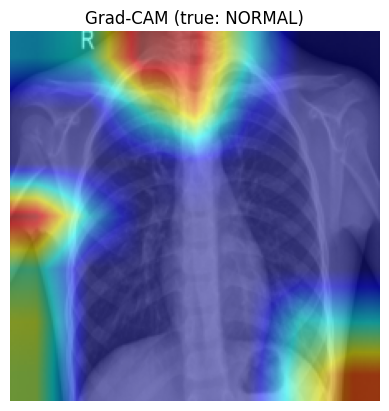

In [10]:
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])
img, label = test_ds[0]
g = cam(input_tensor=img.unsqueeze(0).to(device), targets=[ClassifierOutputTarget(1)])[0]
rgb = (img.numpy().transpose(1,2,0)*STD + MEAN).clip(0,1)
plt.imshow(show_cam_on_image(rgb, g, use_rgb=True))
plt.title(f"Grad-CAM (true: {test_ds.classes[label]})"); plt.axis("off"); plt.show()

In [11]:
from sklearn.metrics import f1_score
best_t, best_f1 = 0.5, 0
for t in np.arange(0.3, 0.9, 0.05):
    preds = (all_probs >= t).astype(int)
    f = f1_score(all_true, preds, average="macro")
    if f > best_f1: best_t, best_f1 = t, f
print("Best threshold:", round(best_t,2))
final = (all_probs >= best_t).astype(int)
print("Tuned accuracy:", round((final==all_true).mean(),4))

Best threshold: 0.9
Tuned accuracy: 0.8686
